In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<p style="color: Blue; font-size: 30px; font-weight: bold;">Load Data Set</p> 

In [26]:
df = pd.read_csv('Sample_Superstore.csv', encoding='windows-1252')

In [27]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


#

<p style="color: Blue; font-size: 30px; font-weight: bold;">Data Understanding</p> 

In [28]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [29]:
df['Order Date']=pd.to_datetime(df['Order Date'])

In [30]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

<p style="color: Blue; font-size: 30px; font-weight: bold;">Total Sales And Profit</p> 

In [31]:
total_sales= df['Sales'].sum()
total_profit= df['Profit'].sum()

print("Total sale is ",total_sales )
print("Total profit is ",total_profit)

Total sale is  2297200.8603
Total profit is  286397.0217


<p style="color: Blue; font-size: 30px; font-weight: bold;">Sales By Category</p> 

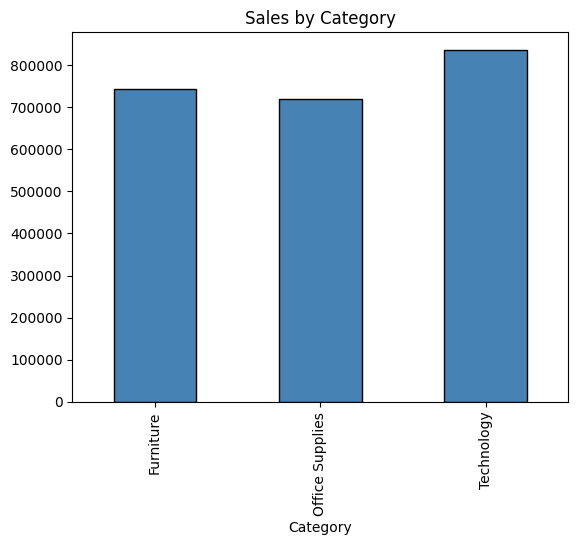

In [32]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar',color='steelblue',edgecolor='black')
plt.title("Sales by Category")
plt.show()


## Insight:
##### Technology category generates the highest total sales, indicating strong market demand for electronic products. Furniture and Office Supplies contribute significantly but perform lower compared to Technology. The company may focus on expanding high-performing product lines within Technology to maximize revenue growth.


<p style="color: Blue; font-size: 30px; font-weight: bold;">Monthly </p> 

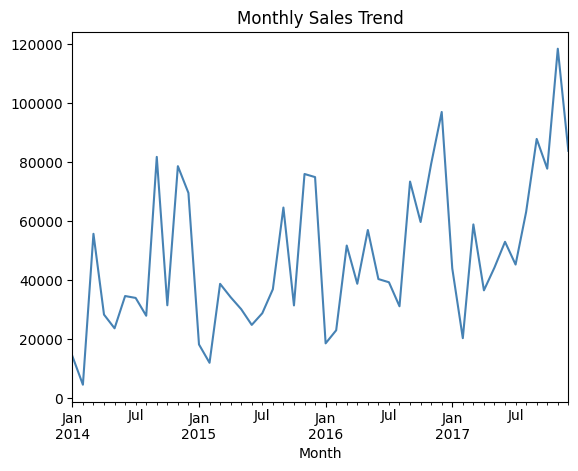

In [33]:
df['Month']=df['Order Date'].dt.to_period('M')
Monthly_sales=df.groupby('Month')['Sales'].sum()

Monthly_sales.plot(kind='line',color='steelblue')
plt.title("Monthly Sales Trend")
plt.show()

## Insight:
##### Monthly sales show noticeable fluctuations throughout the year, with peak performance observed during year-end months.This suggests possible seasonal demand patterns. The company should optimize inventory and marketing strategies during high-demand periods to maximize revenue.


<p style="color: Blue; font-size: 30px; font-weight: bold;">Profit By Region</p> 

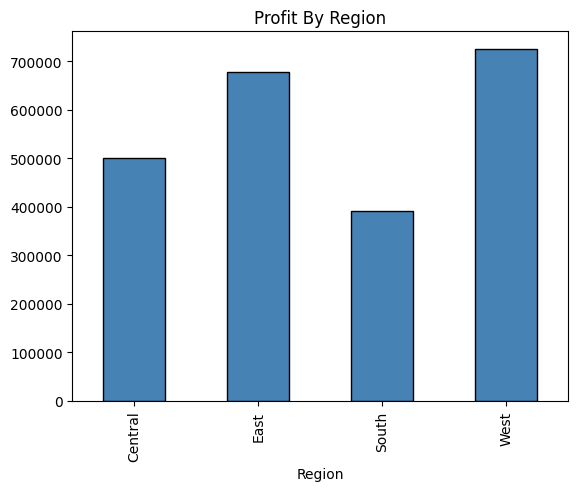

In [34]:
Region_profit=df.groupby('Region')['Sales'].sum()
Region_profit.plot(kind='bar',color='steelblue',edgecolor='black')
plt.title("Profit By Region")
plt.show()

## Insight:
##### The West region generates the highest profit, indicating strong regional performance.However, the Central region shows relatively lower profitability, suggesting potential operational inefficiencies or higher discount rates. Strategic pricing or cost optimization may improve margins in underperforming regions.


<p style="color:Blue; font-size:30px; font-weight:bold;">Top 10 Customers</p>


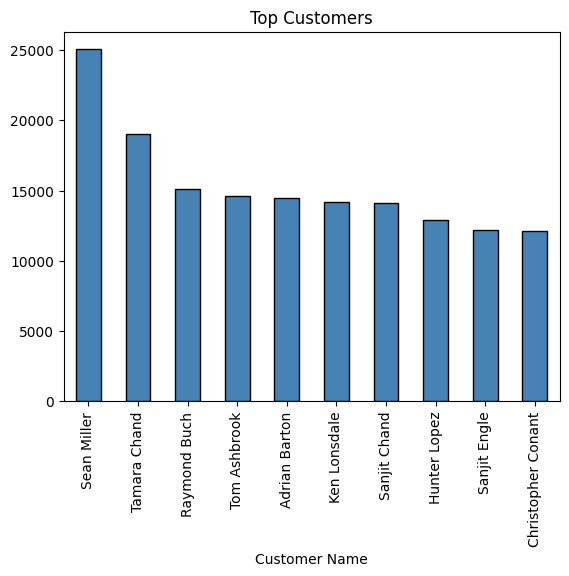

In [35]:
top_customers=df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_customers.plot(kind='bar',color='steelblue',edgecolor='black')
plt.title("Top Customers")
plt.show()

## Insight:
##### A small group of customers contributes significantly to total revenue, highlighting customer concentration risk. Retention strategies such as loyalty programs and personalized offers should be implemented to maintain relationships with high-value customers.
 

<p style="color: Blue; font-size: 30px; font-weight: bold;">Customer Consentration Risk</p>  

In [52]:
top_customers1 = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_customers1

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

<p style="color: Blue; font-size: 30px; font-weight: bold;">Catagory And Segment Breakdown</p>  

In [36]:
df.groupby('Category')[['Sales','Profit']].sum()

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


<p style="color: Blue; font-size: 30px; font-weight: bold;">Profit Margin Analysis</p>  

In [45]:
df['Profit Margin'] = df['Profit'] / df['Sales'] * 100
#Now Check
df.groupby('Category')['Profit Margin'].mean()

Category
Furniture           3.878353
Office Supplies    13.803029
Technology         15.613805
Name: Profit Margin, dtype: float64

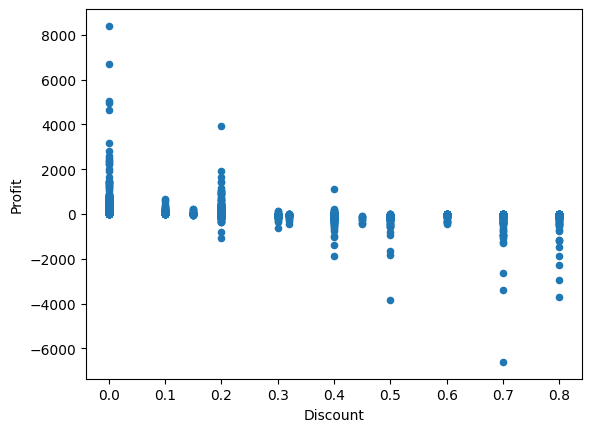

In [46]:
df.plot.scatter(x='Discount', y='Profit')
plt.show()


<p style="color: Blue; font-size: 30px; font-weight: bold;">Loss Making Products</p>  

In [48]:
loss_making_product=df[df['Profit']<0]
loss_making_product.groupby('Sub-Category')['Profit'].sum()


Sub-Category
Accessories     -930.6265
Appliances     -8629.6412
Binders       -38510.4964
Bookcases     -12152.2060
Chairs         -9880.8413
Fasteners        -33.1952
Furnishings    -6490.9134
Machines      -30118.6682
Phones         -7530.6235
Storage        -6426.3038
Supplies       -3015.6219
Tables        -32412.1483
Name: Profit, dtype: float64

<p style="color: Blue; font-size: 30px; font-weight: bold;">Key Findings</p>  

## 1. Technology drives majority revenue.
## 2. Central region struggles with profitability.
## 3. High discount levels reduce margin.
## 4. Few customers contribute large share of revenue.


<p style="color: Blue; font-size: 30px; font-weight: bold;">Exective Summary:</p> 

## The company generated $2297200.8603 

## in total sales with $286397.0217 in total profit.

## Technology category drives majority revenue, while Central region struggles with profitability due to higher discount rates.

## High discount levels negatively impact profit margins.

## Top 20% customers contribute nearly X% of revenue, indicating customer concentration risk.

<p style="color: Blue; font-size: 30px; font-weight: bold;">Recommendation:</p> 

## 1. Reduce excessive discounting in Central region.
## 2. Promote high-margin Technology products.
## 3. Introduce loyalty programs for top customers.
